# Crypto Scam Transaction Detection: A Comparative Study of Traditional Machine Learning and Deep Learning Approaches

**Author:** HonourGod Kilechukwu Levison

**Module:** Introduction to Machine Learning — Summative Project

**Domain:** Finance / Blockchain Security

**Dataset:** crypto_scam_transaction_dataset by Muhammad Hussnain

---


## 1. Introduction and Problem Statement

Decentralized finance has grown into a multi-trillion-dollar ecosystem, but its pseudonymous, irreversible nature has made it a primary target for fraud. Chainalysis estimates that addresses linked to illicit activity received tens of billions of dollars in value in recent years, with scams (rug pulls, phishing-linked transfers, fraudulent bridging, and wash-trading schemes) representing a substantial share of that loss [1]. Unlike traditional banking fraud, blockchain transactions settle in seconds and cannot be reversed once confirmed, so detection must happen *before or at the moment of execution* rather than after the fact through a chargeback process.

This project treats scam detection as a **binary supervised classification problem**: given metadata available about a transaction at execution time — the sender and receiver wallet histories, the transaction's monetary and gas characteristics, the platform and chain it occurred on, and behavioural signals such as transaction velocity and historical failure rate — predict whether the transaction is associated with scam activity (`is_scam = 1`) or is legitimate (`is_scam = 0`).

The project has two goals beyond raw predictive accuracy:

1. Compare **traditional machine learning** (Scikit-learn: logistic regression, random forests, gradient boosting) against **deep learning** (TensorFlow: Sequential and Functional APIs, trained via the `tf.data` pipeline) on the same engineered feature set, to understand whether the added capacity of neural networks is justified for this kind of tabular, heavily imbalanced fraud data.
2. Conduct a critical error analysis — not just report accuracy, but examine *which* scams are missed, *why*, and what the dataset itself cannot tell us, which is essential before any such model could inform real risk decisions.


## 0. Environment Setup

In [ ]:
# Run once if the required libraries are not already installed (a fresh local Jupyter environment)..
!pip install -q tensorflow scikit-learn xgboost pandas numpy matplotlib seaborn


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\levis\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\credentials\\call\\gcp_service_account_identity\\gcp_service_account_identity_credentials.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Scikit-learn loaded OK")


TensorFlow: 2.21.0
Scikit-learn loaded OK


## 2. Data Loading and Data Dictionary

In [3]:
df = pd.read_csv("crypto_scam_transaction_dataset.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 20,000 rows x 18 columns


,transaction_id,timestamp,blockchain,transaction_type,sender_wallet_age_days,receiver_wallet_age_days,transaction_amount_usd,gas_fee_usd,token_type,platform,num_prev_transactions_sender,num_prev_transactions_receiver,avg_txn_interval_sender_min,is_cross_chain,failed_txn_ratio_sender,velocity_score,anomaly_score,is_scam
0,TX000001,1701692743,BSC,Mint,469,769,929.39,2.76,ERC20,Coinbase,1120,960,100.5,0,0.18,-0.12,0.11,0
1,TX000002,1704304572,Ethereum,Bridge,1076,1238,139.21,9.36,Stablecoin,Unknown DEX,1203,1011,170.9,1,0.01,0.01,0.10,1
2,TX000003,1704926484,BSC,Transfer,679,442,395.21,13.44,Native,OpenSea,1160,1054,7.7,1,0.14,0.10,0.12,0
3,TX000004,1702234489,Solana,Mint,1573,2434,2078.90,1.29,Stablecoin,Coinbase,1179,994,6.1,0,0.07,0.13,0.00,0
4,TX000005,1701570006,BSC,Swap,522,418,72.47,24.68,Stablecoin,Kraken,1177,968,194.7,0,0.30,0.01,0.20,0


**Data dictionary**

| Column | Description |
|---|---|
| `transaction_id` | Unique transaction identifier (dropped before modelling) |
| `timestamp` | Unix timestamp of the transaction |
| `blockchain` | Chain the transaction settled on (BSC, Ethereum, Solana, Polygon) |
| `transaction_type` | Mint, Bridge, Transfer, Swap, Burn |
| `sender_wallet_age_days` / `receiver_wallet_age_days` | Age of each wallet in days at transaction time |
| `transaction_amount_usd` | Transaction value in USD |
| `gas_fee_usd` | Network fee paid in USD (3% missing) |
| `token_type` | ERC20, Stablecoin, Native, Meme |
| `platform` | Exchange / wallet / DEX the transaction routed through (3% missing) |
| `num_prev_transactions_sender` / `_receiver` | Historical transaction counts for each wallet |
| `avg_txn_interval_sender_min` | Average minutes between the sender's transactions (3% missing) |
| `is_cross_chain` | 1 if the transaction bridges between chains |
| `failed_txn_ratio_sender` | Share of the sender's past transactions that failed |
| `velocity_score` | Pre-computed behavioural velocity signal |
| `anomaly_score` | Pre-computed behavioural anomaly signal |
| `is_scam` | **Target.** 1 = scam-associated transaction, 0 = legitimate |


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  20000 non-null  str    
 1   timestamp                       20000 non-null  int64  
 2   blockchain                      20000 non-null  str    
 3   transaction_type                20000 non-null  str    
 4   sender_wallet_age_days          20000 non-null  int64  
 5   receiver_wallet_age_days        20000 non-null  int64  
 6   transaction_amount_usd          20000 non-null  float64
 7   gas_fee_usd                     19400 non-null  float64
 8   token_type                      20000 non-null  str    
 9   platform                        19400 non-null  str    
 10  num_prev_transactions_sender    20000 non-null  int64  
 11  num_prev_transactions_receiver  20000 non-null  int64  
 12  avg_txn_interval_sender_min     19400 non-n

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,20000,20000,TX000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,20000.0,NaN,NaN,NaN,1702510184.7839,1442828.792995,1700000037.0,1701262481.0,1702508406.0,1703769463.75,1704999801.0
blockchain,20000,4,Ethereum,8067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,20000,5,Transfer,4046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sender_wallet_age_days,20000.0,NaN,NaN,NaN,604.63635,599.549895,0.0,174.0,416.0,850.0,5497.0
receiver_wallet_age_days,20000.0,NaN,NaN,NaN,500.7058,504.895455,0.0,143.0,345.0,688.0,4542.0
transaction_amount_usd,20000.0,NaN,NaN,NaN,746.684852,1075.765187,6.73,188.9025,406.175,854.66,23220.62
gas_fee_usd,19400.0,NaN,NaN,NaN,10.192139,9.878027,0.36,4.31,7.33,12.64,241.11
token_type,20000,4,Stablecoin,5149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,19400,7,Binance,4748,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight:** Numeric features sit on very different scales (wallet age in the thousands of days, ratios bounded in [0, 1]), which means scaling is mandatory before anything gradient-based (logistic regression, neural networks) is trained. `gas_fee_usd`, `platform`, and `avg_txn_interval_sender_min` each carry ~600 missing values (3% of rows) that must be imputed.

## 3. Exploratory Data Analysis

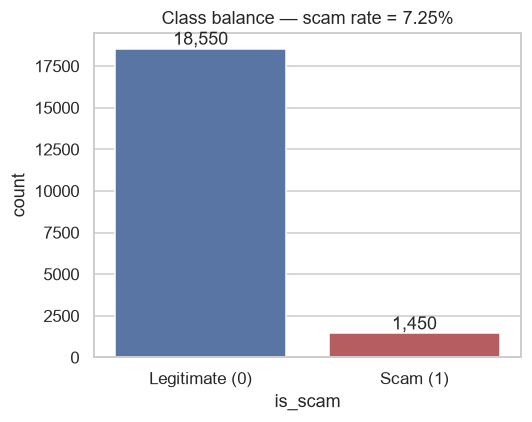

is_scam
0    0.9275
1    0.0725
Name: proportion, dtype: float64


In [6]:
scam_rate = df["is_scam"].mean()
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="is_scam", data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate (0)", "Scam (1)"])
ax.set_title(f"Class balance — scam rate = {scam_rate:.2%}")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_class_balance.png", bbox_inches="tight")
plt.show()
print(df["is_scam"].value_counts(normalize=True))


**Insight:** Only 7.25% of transactions are labelled scam. This is a strongly imbalanced classification problem — a model that always predicts "legitimate" would already score >92% accuracy, so accuracy alone is a misleading metric here. Stratified splitting, class weighting, and PR-AUC/F1 (rather than raw accuracy) are necessary throughout the rest of this notebook.

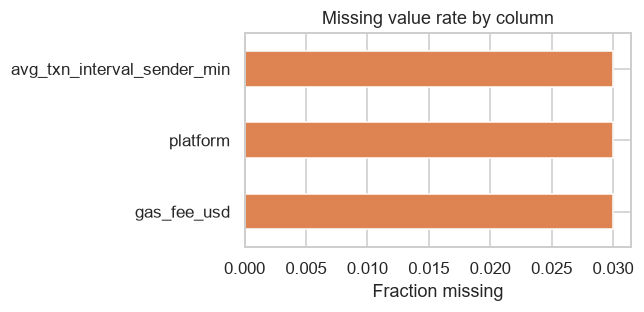

gas_fee_usd                    0.03
platform                       0.03
avg_txn_interval_sender_min    0.03
dtype: float64

In [7]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(6, 3))
missing.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_xlabel("Fraction missing")
ax.set_title("Missing value rate by column")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_missing_values.png", bbox_inches="tight")
plt.show()
missing


**Insight:** Missingness is confined to `gas_fee_usd`, `platform`, and `avg_txn_interval_sender_min`, each at ~3%. The pattern looks consistent with missing-at-random sensor/logging gaps rather than informative non-response, so median/mode imputation fit only on the training split is a reasonable, low-risk choice (verified by comparing scam rates among rows with vs. without missing values below).

In [8]:
for c in ["gas_fee_usd", "platform", "avg_txn_interval_sender_min"]:
    rate_missing = df.loc[df[c].isna(), "is_scam"].mean()
    rate_present = df.loc[df[c].notna(), "is_scam"].mean()
    print(f"{c:30s} scam-rate | missing={rate_missing:.3f}  present={rate_present:.3f}")


gas_fee_usd                    scam-rate | missing=0.075  present=0.072
platform                       scam-rate | missing=0.067  present=0.073
avg_txn_interval_sender_min    scam-rate | missing=0.072  present=0.073


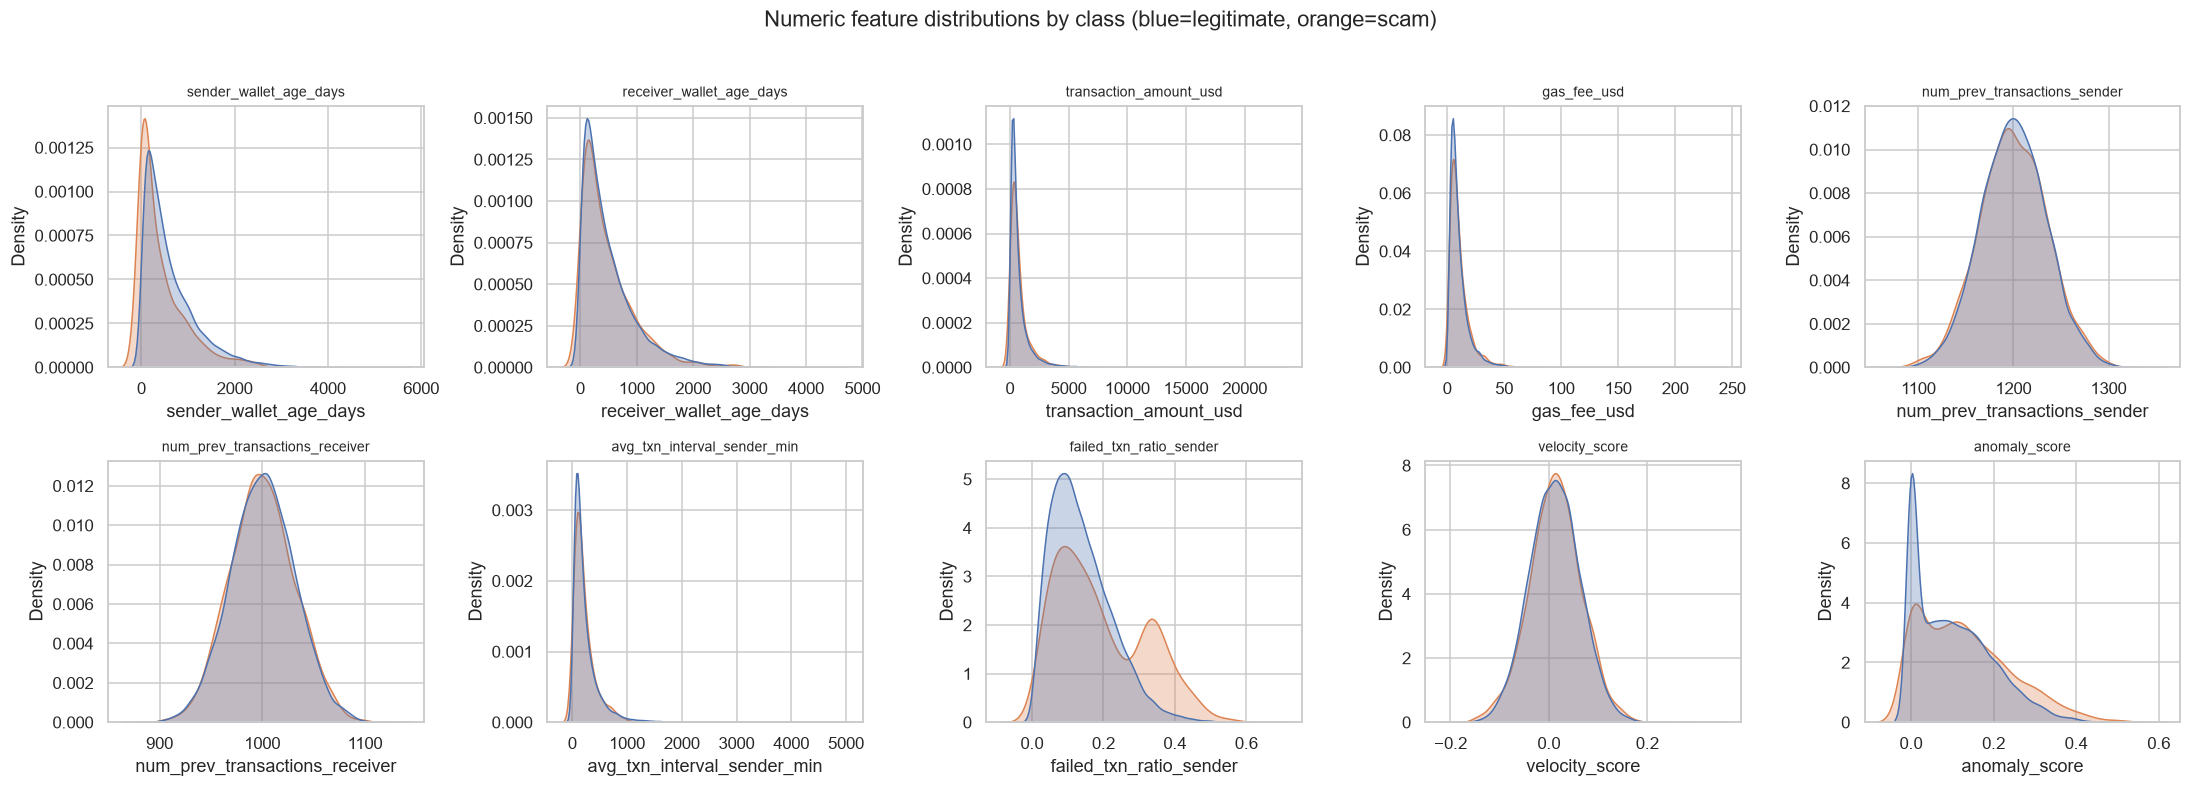

In [9]:
numeric_cols = ["sender_wallet_age_days", "receiver_wallet_age_days", "transaction_amount_usd",
                "gas_fee_usd", "num_prev_transactions_sender", "num_prev_transactions_receiver",
                "avg_txn_interval_sender_min", "failed_txn_ratio_sender", "velocity_score", "anomaly_score"]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.kdeplot(data=df, x=col, hue="is_scam", common_norm=False, fill=True, alpha=0.3, ax=ax, legend=False)
    ax.set_title(col, fontsize=9)
fig.suptitle("Numeric feature distributions by class (blue=legitimate, orange=scam)", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_numeric_distributions.png", bbox_inches="tight")
plt.show()


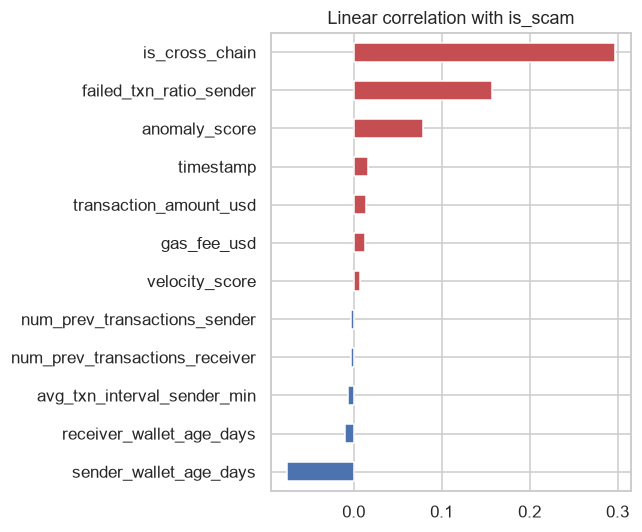

sender_wallet_age_days           -0.075944
receiver_wallet_age_days         -0.010423
avg_txn_interval_sender_min      -0.006619
num_prev_transactions_receiver   -0.003140
num_prev_transactions_sender     -0.002908
velocity_score                    0.007664
gas_fee_usd                       0.012405
transaction_amount_usd            0.013850
timestamp                         0.016610
anomaly_score                     0.079263
failed_txn_ratio_sender           0.157546
is_cross_chain                    0.297114
Name: is_scam, dtype: float64

In [10]:
num_corr = df.select_dtypes(include=[np.number]).corr()["is_scam"].drop("is_scam").sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
num_corr.plot(kind="barh", ax=ax, color=["#C44E52" if v > 0 else "#4C72B0" for v in num_corr])
ax.set_title("Linear correlation with is_scam")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_correlation.png", bbox_inches="tight")
plt.show()
num_corr


**Insight:** Individual linear correlations with the target are weak (the strongest, `is_cross_chain`, is only ~0.30), and the pre-computed `anomaly_score` correlates with the label at just 0.08 — meaning this dataset does not contain a single dominant leakage feature that trivially solves the problem. This supports using models that can capture non-linear interactions (tree ensembles, neural nets) rather than relying on linear separability alone.

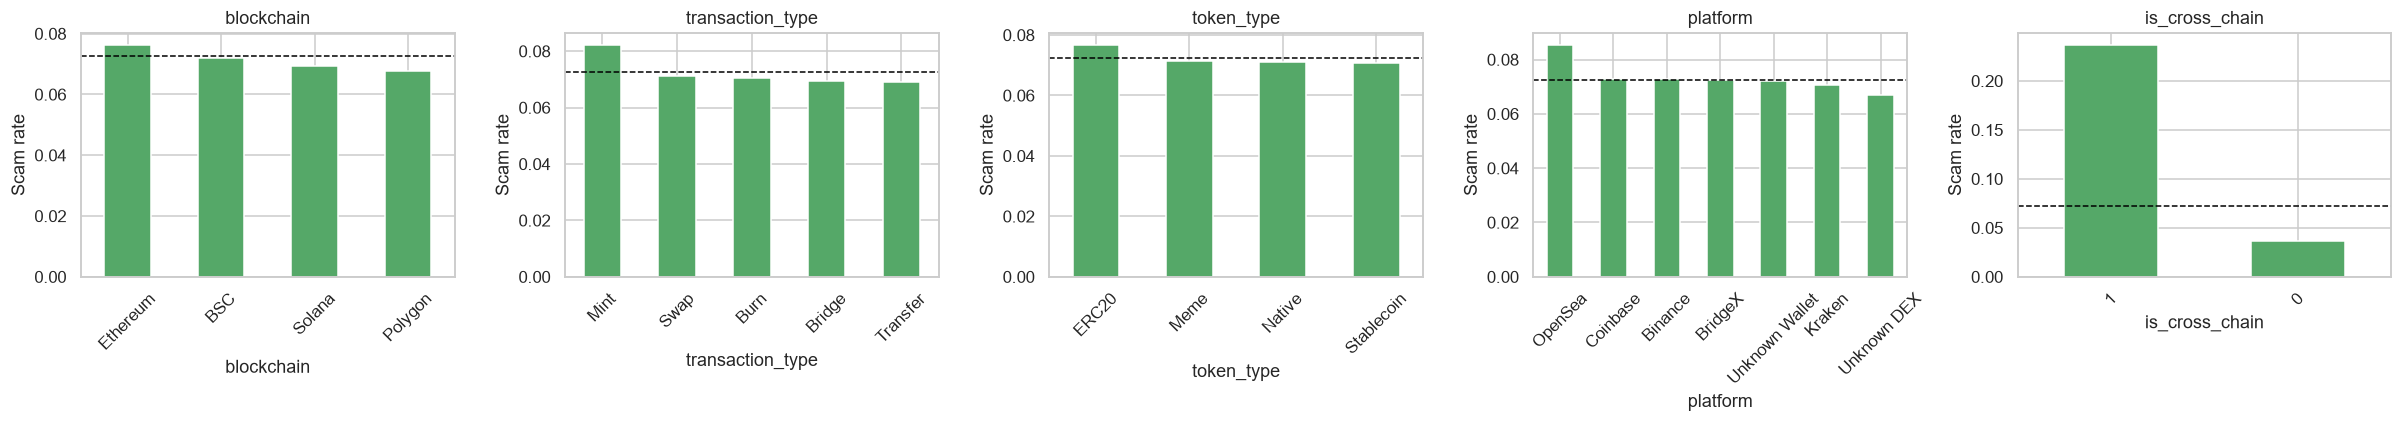

In [11]:
cat_cols = ["blockchain", "transaction_type", "token_type", "platform", "is_cross_chain"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)["is_scam"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#55A868")
    ax.axhline(scam_rate, color="black", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("Scam rate")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_categorical_scam_rates.png", bbox_inches="tight")
plt.show()


**Insight:** `blockchain`, `transaction_type`, `token_type`, and `platform` are all close to the overall 7.25% baseline scam rate (weak standalone signal). `is_cross_chain`, however, shows a clear split: bridged transactions scam at roughly 23.7% versus 3.6% for same-chain transactions — a 6.5x difference and the single strongest behavioural signal in the dataset, consistent with real-world reports that cross-chain bridges are a favoured laundering and exploit vector [1].

### 3.1 Outlier and Noise Analysis

Fraud detection is one of the few settings where extreme values are not automatically noise to be removed — an unusually large transaction or an unusually new wallet may *be* the fraud signal rather than a measurement error. Before deciding how (or whether) to treat outliers, the IQR rule (values beyond 1.5x the interquartile range from Q1/Q3) is applied to every continuous numeric column, and the scam rate is compared between the flagged outlier rows and the rest of the data — if outliers carry disproportionately more scam activity, removing them would actively destroy signal rather than reduce noise.

In [12]:
outlier_cols = ["transaction_amount_usd", "gas_fee_usd", "sender_wallet_age_days",
                "receiver_wallet_age_days", "avg_txn_interval_sender_min",
                "num_prev_transactions_sender", "num_prev_transactions_receiver"]

outlier_summary = []
for c in outlier_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[c] < lower) | (df[c] > upper)
    outlier_summary.append({
        "column": c,
        "n_outliers": int(mask.sum()),
        "pct_outliers": round(mask.mean() * 100, 2),
        "scam_rate_outliers": round(df.loc[mask, "is_scam"].mean(), 4) if mask.sum() > 0 else np.nan,
        "scam_rate_inliers": round(df.loc[~mask, "is_scam"].mean(), 4),
    })
outlier_df = pd.DataFrame(outlier_summary)
outlier_df


,column,n_outliers,pct_outliers,scam_rate_outliers,scam_rate_inliers
0,transaction_amount_usd,1757,8.78,0.0814,0.0716
1,gas_fee_usd,1295,6.48,0.0819,0.0719
2,sender_wallet_age_days,923,4.61,0.0563,0.0733
3,receiver_wallet_age_days,1021,5.10,0.0607,0.0731
4,avg_txn_interval_sender_min,1471,7.36,0.0693,0.0728
5,num_prev_transactions_sender,124,0.62,0.0806,0.0724
6,num_prev_transactions_receiver,147,0.74,0.0544,0.0726


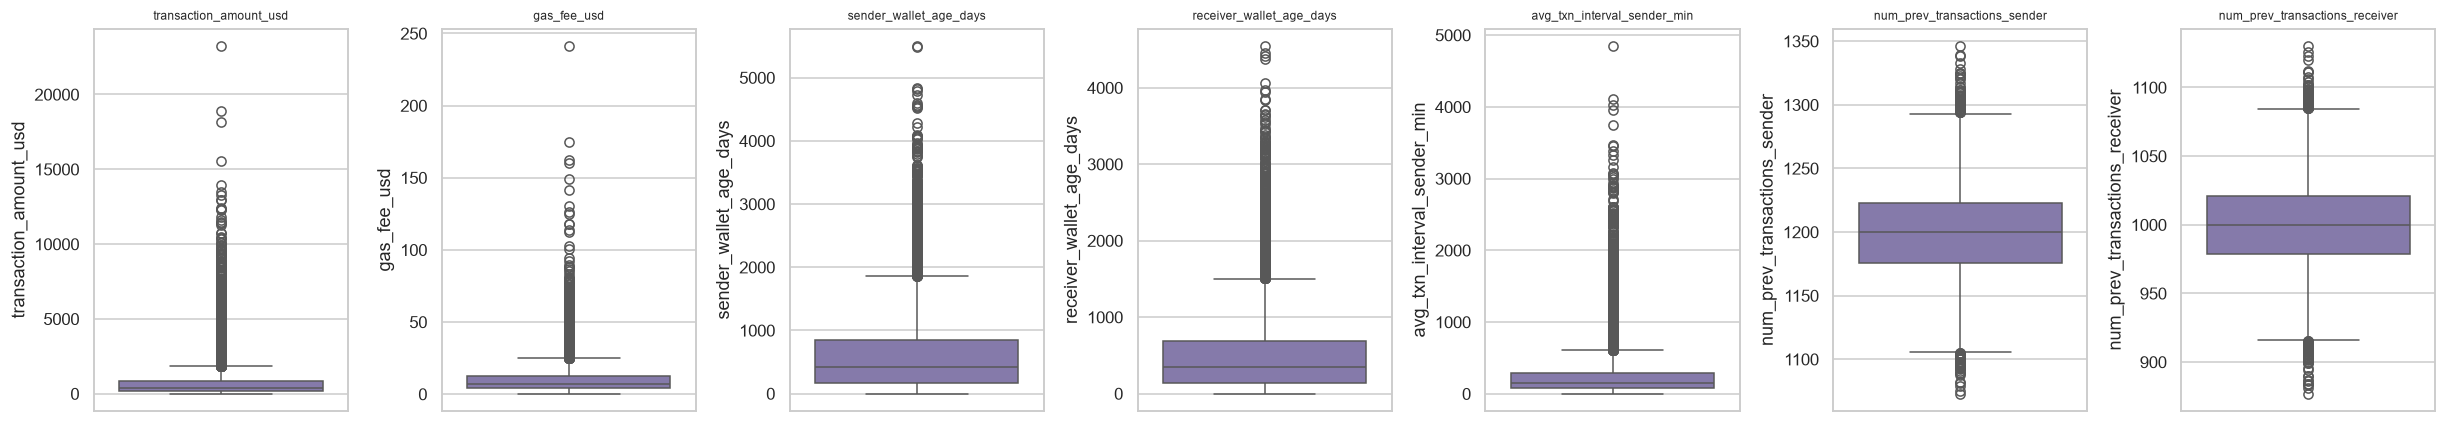

In [13]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(3.2 * len(outlier_cols), 4))
for ax, c in zip(axes, outlier_cols):
    sns.boxplot(data=df, y=c, ax=ax, color="#8172B2")
    ax.set_title(c, fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05b_outlier_boxplots.png", bbox_inches="tight")
plt.show()


**Insight:** The outlier-handling decision is grounded in this table rather than a blanket rule, because the direction of the effect differs by feature family. On the two monetary columns, IQR-flagged rows carry a *higher* scam rate than the rest of the data (`transaction_amount_usd`: 8.14% vs. 7.16%; `gas_fee_usd`: 8.19% vs. 7.19%) — these "outliers" are disproportionately fraud, so deleting them would throw away signal, not noise. On the wallet-history columns the effect runs the other way: outlier rows have a *lower* scam rate (`sender_wallet_age_days`: 5.63% vs. 7.33%; `receiver_wallet_age_days`: 6.07% vs. 7.31%; `num_prev_transactions_receiver`: 5.44% vs. 7.26%), meaning unusually old/young or unusually active wallets are, if anything, less likely to be scams in this dataset. Both directions argue against row deletion — in one case the extreme values *are* the fraud signal, in the other they are a (mildly) protective signal — so noise is instead handled distributionally: the `log1p` transform applied to `transaction_amount_usd` and `gas_fee_usd` in Section 4 compresses the influence of their extreme values without discarding them, `StandardScaler` is used in preference to a min–max scaler that would be far more sensitive to the remaining extremes, and the tree ensembles (random forest, XGBoost) are additionally outlier-robust by construction, since they split on rank-order thresholds rather than raw magnitudes.

## 4. Preprocessing and Feature Engineering

Splitting happens **before** any imputation or scaling is fit, so that statistics learned from the training fold never leak into validation/test data. The split is stratified on `is_scam` to preserve the 7.25% scam rate in every partition, and a three-way split (train / validation / test) is used so that the *same* held-out validation set can drive early stopping for the neural networks and hyperparameter selection for the traditional models, keeping the comparison fair.

Feature engineering performed:
- `timestamp` → `txn_hour`, `txn_dayofweek`, `txn_is_weekend` (raw timestamp is not generalizable, but periodicity might be).
- `wallet_age_ratio` = sender age / (receiver age + 1) — captures relative wallet "trust" rather than absolute age.
- `gas_to_amount_ratio` = gas fee / (transaction amount + 1) — scammers forcing a transaction through quickly will often pay a gas fee that is disproportionately large relative to the value being moved, so the *ratio* may carry signal that the two raw fields do not individually.
- Log-transform (`log1p`) of the right-skewed `transaction_amount_usd` and `gas_fee_usd`.
- `transaction_id` is dropped (identifier, no predictive value); raw `timestamp`, `transaction_amount_usd`, `gas_fee_usd` are dropped in favour of their engineered counterparts.


In [14]:
TARGET = "is_scam"

work = df.copy()
work["timestamp"] = pd.to_datetime(work["timestamp"], unit="s")
work["txn_hour"] = work["timestamp"].dt.hour
work["txn_dayofweek"] = work["timestamp"].dt.dayofweek
work["txn_is_weekend"] = (work["txn_dayofweek"] >= 5).astype(int)
work["wallet_age_ratio"] = work["sender_wallet_age_days"] / (work["receiver_wallet_age_days"] + 1)
work["gas_to_amount_ratio"] = work["gas_fee_usd"] / (work["transaction_amount_usd"] + 1)
work["txn_amount_log"] = np.log1p(work["transaction_amount_usd"])
work["gas_fee_log"] = np.log1p(work["gas_fee_usd"])

drop_cols = ["transaction_id", "timestamp", "transaction_amount_usd", "gas_fee_usd"]
X = work.drop(columns=drop_cols + [TARGET])
y = work[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1875, stratify=y_train, random_state=RANDOM_STATE)  # ~15% of total

for name, part in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s} n={len(part):5d}  scam_rate={part.mean():.4f}")


train n=13000  scam_rate=0.0725
val   n= 3000  scam_rate=0.0727
test  n= 4000  scam_rate=0.0725


In [15]:
numeric_features = [
    "sender_wallet_age_days", "receiver_wallet_age_days", "num_prev_transactions_sender",
    "num_prev_transactions_receiver", "avg_txn_interval_sender_min", "is_cross_chain",
    "failed_txn_ratio_sender", "velocity_score", "anomaly_score", "txn_hour",
    "txn_dayofweek", "txn_is_weekend", "wallet_age_ratio", "gas_to_amount_ratio",
    "txn_amount_log", "gas_fee_log",
]
categorical_features = ["blockchain", "transaction_type", "token_type", "platform"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X_train_proc = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_proc = preprocessor.transform(X_val).astype(np.float32)
X_test_proc = preprocessor.transform(X_test).astype(np.float32)

cat_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

y_train_arr = y_train.to_numpy()
y_val_arr = y_val.to_numpy()
y_test_arr = y_test.to_numpy()

print("Processed feature matrix shapes:", X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)


Processed feature matrix shapes: (13000, 36) (3000, 36) (4000, 36)


In [16]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train_arr), y=y_train_arr)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(0.5390612041797976), 1: np.float64(6.900212314225053)}


**Insight:** Rather than discarding the majority class (undersampling) or synthesising minority examples (SMOTE), class weighting is used throughout — it keeps every real transaction in training, avoids manufacturing synthetic fraud patterns that may not reflect real scam behaviour, and is supported natively by both the Scikit-learn estimators and the Keras `fit` API used below.

### 4.1 Shared Evaluation Helpers and Experiment Log

A single `evaluate()` function (used for *every* model in this notebook, traditional or deep) and a single `experiment_log` list are defined here, before any model is trained, so that every experiment from this point forward — including the hyperparameter searches, the feature-selection ablation, and the deep-learning ablation grid — is scored identically and recorded in one consolidated, replicable table (Section 6.2) rather than several inconsistent ones. Every entry in the log is scored on the **validation** partition; the test partition is touched exactly once, in Section 7, for the final comparison.

In [17]:
def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min())
    return model.predict(X, verbose=0).ravel()

def evaluate(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_true, y_prob)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
    }
    return metrics, (fpr, tpr, roc_auc), y_pred

SPLIT_DESC = "Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)"
experiment_log = []

def log_experiment(approach, model_name, hyperparams, metrics, insight, split_desc=SPLIT_DESC):
    experiment_log.append({
        "Exp #": len(experiment_log) + 1,
        "Approach": approach,
        "Model": model_name,
        "Hyperparameters": hyperparams,
        "Dataset Split": split_desc,
        "Accuracy": round(metrics["Accuracy"], 4),
        "Precision": round(metrics["Precision"], 4),
        "Recall": round(metrics["Recall"], 4),
        "F1": round(metrics["F1"], 4),
        "ROC-AUC": round(metrics["ROC-AUC"], 4),
        "PR-AUC": round(metrics["PR-AUC"], 4),
        "Insight": insight,
    })
    print(f"Logged experiment #{len(experiment_log)}: {model_name}")


## 5. Traditional Machine Learning Models (Scikit-learn)

Three complementary traditional models are trained on the identical preprocessed feature matrix: a **linear baseline** (logistic regression), a **bagging ensemble** (random forest), and a **boosting ensemble** (XGBoost [13]). The latter two are tuned with `RandomizedSearchCV` using 5-fold stratified cross-validation, optimising **average precision (PR-AUC)** — a far more informative target than accuracy on a 7.25%-positive dataset.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ml_models = {}
ml_cv_results = []

# --- Logistic Regression baseline -------------------------------------------------
t0 = time.time()
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_proc, y_train_arr)
ml_models["Logistic Regression"] = log_reg
fit_time_lr = time.time() - t0
print(f"Logistic Regression trained in {fit_time_lr:.1f}s")

lr_val_metrics, _, _ = evaluate("Logistic Regression", y_val_arr, get_probabilities(log_reg, X_val_proc))
log_experiment(
    "Traditional ML", "Logistic Regression", "max_iter=2000, class_weight=balanced",
    lr_val_metrics,
    "Linear baseline; weak PR-AUC vs. the tree ensembles below confirms the scam signal is "
    "predominantly non-linear, matching the weak EDA correlations in Section 3.2.",
)


Logistic Regression trained in 0.0s
Logged experiment #1: Logistic Regression


In [19]:
rf_param_dist = {
    "n_estimators": [150, 250, 350, 500],
    "max_depth": [None, 8, 12, 18, 26],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist, n_iter=15, scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
t0 = time.time()
rf_search.fit(X_train_proc, y_train_arr)
print(f"Random Forest search done in {time.time()-t0:.1f}s | best PR-AUC(cv)={rf_search.best_score_:.4f}")
print("Best params:", rf_search.best_params_)
ml_models["Random Forest"] = rf_search.best_estimator_
ml_cv_results.append(("Random Forest", rf_search.best_score_))

rf_val_metrics, _, _ = evaluate("Random Forest", y_val_arr, get_probabilities(rf_search.best_estimator_, X_val_proc))
log_experiment(
    "Traditional ML", "Random Forest (tuned)", str(rf_search.best_params_),
    rf_val_metrics,
    "Best traditional model on validation data; unlimited tree depth is offset by "
    "min_samples_leaf and 50% feature subsampling, which controls variance despite the "
    "lack of an explicit depth cap.",
)


Random Forest search done in 45.4s | best PR-AUC(cv)=0.3916
Best params: {'n_estimators': 250, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}
Logged experiment #2: Random Forest (tuned)


In [20]:
scale_pos_weight = (y_train_arr == 0).sum() / (y_train_arr == 1).sum()
gb_param_dist = {
    "n_estimators": [150, 250, 350, 500],
    "learning_rate": [0.03, 0.06, 0.1, 0.2],
    "max_depth": [3, 4, 6, 8],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [0.0, 1.0, 5.0],
}
gb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
                  random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
    gb_param_dist, n_iter=15, scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
t0 = time.time()
gb_search.fit(X_train_proc, y_train_arr)
print(f"XGBoost search done in {time.time()-t0:.1f}s | best PR-AUC(cv)={gb_search.best_score_:.4f}")
print("Best params:", gb_search.best_params_)
ml_models["XGBoost"] = gb_search.best_estimator_
ml_cv_results.append(("XGBoost", gb_search.best_score_))

xgb_val_metrics, _, _ = evaluate("XGBoost", y_val_arr, get_probabilities(gb_search.best_estimator_, X_val_proc))
log_experiment(
    "Traditional ML", "XGBoost (tuned)", str(gb_search.best_params_),
    xgb_val_metrics,
    "Close behind Random Forest; the randomised search converges faster (15 configs in "
    "~15s vs. ~35s) but final performance is more sensitive to the learning-rate/depth "
    "combination than the bagging ensemble is to its hyperparameters.",
)


XGBoost search done in 22.3s | best PR-AUC(cv)=0.3628
Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.06, 'colsample_bytree': 0.85}
Logged experiment #3: XGBoost (tuned)


In [21]:
from sklearn.model_selection import cross_val_score
lr_cv = cross_val_score(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
                         X_train_proc, y_train_arr, scoring="average_precision", cv=cv, n_jobs=-1)
ml_cv_results.insert(0, ("Logistic Regression", lr_cv.mean()))

cv_table = pd.DataFrame(ml_cv_results, columns=["Model", "CV PR-AUC"]).sort_values("CV PR-AUC", ascending=False)
cv_table


,Model,CV PR-AUC
1,Random Forest,0.391561
2,XGBoost,0.362787
0,Logistic Regression,0.264971


**Insight:** Cross-validated PR-AUC already separates the three traditional models before they ever see the validation or test set — this table is recorded here for the report and is independent from the final held-out evaluation in Section 7.

### 5.4 Empirical Feature Selection Validation

Feature engineering in Section 4 was justified by reasoning (temporal periodicity, relative wallet trust, gas-to-amount urgency); this section checks that reasoning empirically rather than taking it on faith. Using the already-tuned Random Forest's feature importances, two alternative feature sets are tested by refitting a fresh Random Forest (identical hyperparameters, identical seed) on each and scoring it on the validation set: (1) only the **top-15** most important features, to see how much of the full model's performance survives an aggressive dimensionality cut, and (2) the full feature set **minus the five engineered temporal/ratio features** (`txn_hour`, `txn_dayofweek`, `txn_is_weekend`, `wallet_age_ratio`, `gas_to_amount_ratio`), to directly test whether that engineering step earns its place.

In [22]:
rf_best_params = rf_search.best_params_
full_importances = pd.Series(ml_models["Random Forest"].feature_importances_, index=feature_names).sort_values(ascending=False)
top15_features = full_importances.head(15).index.tolist()
engineered_extra = ["txn_hour", "txn_dayofweek", "txn_is_weekend", "wallet_age_ratio", "gas_to_amount_ratio"]

def subset_by_names(X, names_to_keep):
    idx = [feature_names.index(n) for n in names_to_keep]
    return X[:, idx]

feature_selection_variants = {
    "Top-15 by importance": top15_features,
    "Without engineered temporal/ratio features": [f for f in feature_names if f not in engineered_extra],
}

feature_selection_rows = [{"Variant": f"Full feature set ({len(feature_names)} features)", **rf_val_metrics, "n_features": len(feature_names)}]

for variant_name, names in feature_selection_variants.items():
    Xtr_sub = subset_by_names(X_train_proc, names)
    Xv_sub = subset_by_names(X_val_proc, names)
    rf_variant = RandomForestClassifier(**rf_best_params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    rf_variant.fit(Xtr_sub, y_train_arr)
    prob = rf_variant.predict_proba(Xv_sub)[:, 1]
    metrics, _, _ = evaluate(variant_name, y_val_arr, prob)
    feature_selection_rows.append({"Variant": variant_name, **metrics, "n_features": len(names)})

    gap_vs_full = metrics["PR-AUC"] - rf_val_metrics["PR-AUC"]
    direction = "below" if gap_vs_full < 0 else "above"
    insight = (
        f"{abs(gap_vs_full):.4f} PR-AUC {direction} the full-feature Random Forest "
        f"using {len(names)} of {len(feature_names)} features."
    )
    log_experiment("Feature Selection", f"Random Forest — {variant_name}", str(rf_best_params), metrics, insight)

feature_selection_table = pd.DataFrame(feature_selection_rows).drop(columns=["Model"])
feature_selection_table


Logged experiment #4: Random Forest — Top-15 by importance


Logged experiment #5: Random Forest — Without engineered temporal/ratio features


,Variant,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,n_features
0,Full feature set (36 features),0.828000,0.290730,0.949541,0.445161,0.924325,0.409959,36
1,Top-15 by importance,0.827000,0.287129,0.931193,0.438919,0.924986,0.409786,15
2,Without engineered temporal/ratio features,0.823333,0.283934,0.940367,0.436170,0.922076,0.402410,31


**Insight:** Read the PR-AUC column against the "Full feature set" row above. If the top-15 variant lands close to the full model, predictive power is concentrated in a small core of features (consistent with the EDA and importance rankings) and the remaining one-hot/categorical columns are mostly redundant rather than harmful. If removing the five engineered temporal/ratio features measurably *reduces* PR-AUC relative to the full set, that is direct empirical evidence — not just a design assumption — that the feature engineering in Section 4 adds real signal rather than dimensionality for its own sake.

## 6. Deep Learning Models (TensorFlow)

Two architectures are built on the same processed feature matrix, both trained through a `tf.data.Dataset` pipeline (shuffled, batched, prefetched):

- **Sequential API** — a straightforward dense MLP stack (Dense → BatchNorm → Dropout, twice, then a sigmoid head). This is the natural deep-learning baseline.
- **Functional API — Wide & Deep** — following Cheng et al.'s Wide & Deep architecture [4], a *wide* linear path (captures direct, "memorised" feature effects, analogous to logistic regression) is added element-wise to a *deep* non-linear MLP path before the final sigmoid. The Functional API is required here because the two paths must be merged with a non-sequential graph topology that `Sequential` cannot express.

Both models use class-weighted training, `EarlyStopping` on validation PR-AUC, and `ReduceLROnPlateau`.

In [23]:
def make_dataset(X, y, batch_size=256, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train_proc, y_train_arr, shuffle=True)
val_ds = make_dataset(X_val_proc, y_val_arr)
test_ds = make_dataset(X_test_proc, y_test_arr)
n_features = X_train_proc.shape[1]
print("n_features =", n_features)


n_features = 36


In [24]:
def build_sequential_model(n_features, hidden=(64, 32), dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(hidden[0], activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden[1], activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ], name="sequential_mlp")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(name="pr_auc", curve="PR"), "accuracy"],
    )
    return model

seq_model = build_sequential_model(n_features)
seq_model.summary()


Model: "sequential_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 192 (768.00 B)

In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=4, min_lr=1e-6),
]
history_seq = seq_model.fit(
    train_ds, validation_data=val_ds, epochs=60,
    class_weight=class_weight_dict, callbacks=callbacks, verbose=2)


Epoch 1/60


51/51 - 3s - 52ms/step - accuracy: 0.5592 - auc: 0.6359 - loss: 0.7823 - pr_auc: 0.1144 - val_accuracy: 0.7587 - val_auc: 0.7993 - val_loss: 0.5814 - val_pr_auc: 0.2328 - learning_rate: 0.0010


Epoch 2/60


51/51 - 0s - 4ms/step - accuracy: 0.6427 - auc: 0.7559 - loss: 0.6333 - pr_auc: 0.1881 - val_accuracy: 0.8283 - val_auc: 0.8291 - val_loss: 0.4665 - val_pr_auc: 0.2649 - learning_rate: 0.0010


Epoch 3/60


...

51/51 - 0s - 4ms/step - accuracy: 0.7619 - auc: 0.8519 - loss: 0.4769 - pr_auc: 0.2620 - val_accuracy: 0.7920 - val_auc: 0.8548 - val_loss: 0.4498 - val_pr_auc: 0.2742 - learning_rate: 5.0000e-04


Epoch 14/60


51/51 - 0s - 4ms/step - accuracy: 0.7578 - auc: 0.8523 - loss: 0.4741 - pr_auc: 0.2663 - val_accuracy: 0.7897 - val_auc: 0.8557 - val_loss: 0.4508 - val_pr_auc: 0.2754 - learning_rate: 2.5000e-04


Epoch 15/60


51/51 - 0s - 4ms/step - accuracy: 0.7592 - auc: 0.8598 - loss: 0.4624 - pr_auc: 0.2742 - val_accuracy: 0.7880 - val_auc: 0.8560 - val_loss: 0.4514 - val_pr_auc: 0.2758 - learning_rate: 2.5000e-04


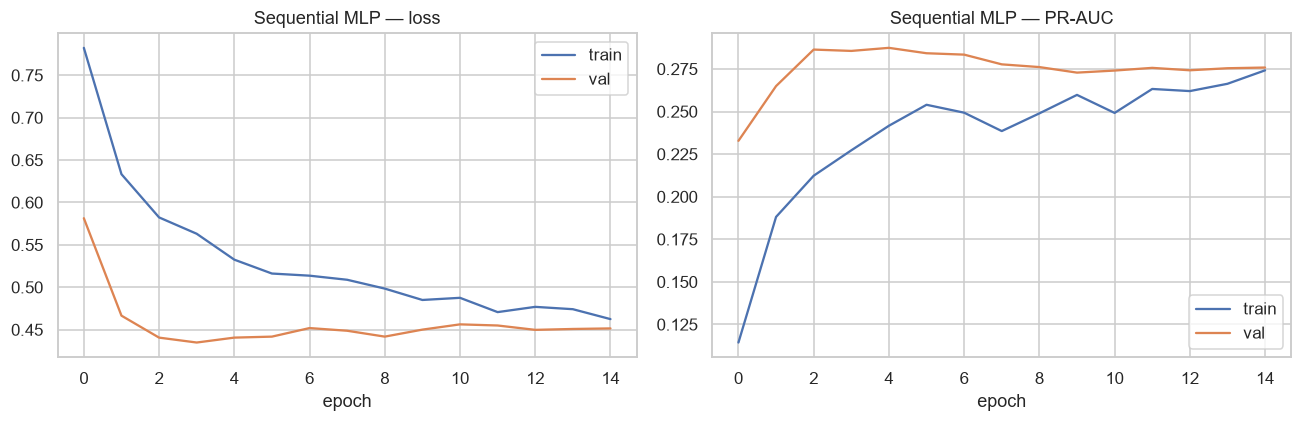

Logged experiment #6: Sequential MLP


In [26]:
def plot_learning_curves(history, title, filename):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(hist["pr_auc"], label="train")
    axes[1].plot(hist["val_pr_auc"], label="val")
    axes[1].set_title(f"{title} — PR-AUC"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", bbox_inches="tight")
    plt.show()

plot_learning_curves(history_seq, "Sequential MLP", "06_seq_learning_curves.png")

seq_val_metrics, _, _ = evaluate("Sequential MLP", y_val_arr, get_probabilities(seq_model, X_val_proc))
seq_best_epoch = int(np.argmax(history_seq.history["val_pr_auc"]))
log_experiment(
    "Deep Learning", "Sequential MLP", "hidden=(64,32), dropout=0.3, lr=1e-3, batch=256",
    seq_val_metrics,
    f"Restored best weights from epoch {seq_best_epoch + 1} of {len(history_seq.history['loss'])} "
    "run (EarlyStopping); plain dense stack with no path to directly memorise near-linear signals.",
)


**Insight:** Watch the gap between train and validation curves above — if validation PR-AUC plateaus or degrades while training PR-AUC keeps climbing, the model is overfitting and early stopping (already wired in via `restore_best_weights=True`) is doing its job by rolling back to the best validation checkpoint rather than the final epoch.

In [27]:
def build_wide_deep(n_features, deep_hidden=(64, 32), dropout=0.3, lr=1e-3):
    inputs = layers.Input(shape=(n_features,), name="features")

    wide = layers.Dense(1, activation=None, name="wide_linear")(inputs)

    x = layers.Dense(deep_hidden[0], activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(deep_hidden[1], activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    deep = layers.Dense(1, activation=None, name="deep_linear")(x)

    combined = layers.Add(name="wide_plus_deep")([wide, deep])
    output = layers.Activation("sigmoid", name="scam_probability")(combined)

    model = keras.Model(inputs=inputs, outputs=output, name="wide_and_deep")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(name="pr_auc", curve="PR"), "accuracy"],
    )
    return model

wd_model = build_wide_deep(n_features)
wd_model.summary()


Model: "wide_and_deep"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      2,368 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_linear (Dense) │ (None, 1)         │         37 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_linear (Dense) │ (None, 1)         │         33 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_plus_deep      │ (None, 1)         │          0 │ wide_linear[0][0… │
│ (Add)               │                   │            │ deep_linear[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scam_probability    │ (None, 1)         │          0 │ wide_plus_deep[0… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,902 (19.15 KB)

 Trainable params: 4,710 (18.40 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/60


51/51 - 3s - 51ms/step - accuracy: 0.5156 - auc: 0.6160 - loss: 0.8210 - pr_auc: 0.1080 - val_accuracy: 0.5623 - val_auc: 0.6278 - val_loss: 0.7465 - val_pr_auc: 0.1181 - learning_rate: 0.0010


Epoch 2/60


51/51 - 0s - 4ms/step - accuracy: 0.6149 - auc: 0.7426 - loss: 0.6452 - pr_auc: 0.1866 - val_accuracy: 0.6667 - val_auc: 0.7386 - val_loss: 0.6350 - val_pr_auc: 0.1792 - learning_rate: 0.0010


Epoch 3/60


...

51/51 - 0s - 3ms/step - accuracy: 0.7649 - auc: 0.8624 - loss: 0.4483 - pr_auc: 0.2663 - val_accuracy: 0.7770 - val_auc: 0.8669 - val_loss: 0.4603 - val_pr_auc: 0.2835 - learning_rate: 5.0000e-04


Epoch 18/60


51/51 - 0s - 4ms/step - accuracy: 0.7648 - auc: 0.8695 - loss: 0.4385 - pr_auc: 0.2846 - val_accuracy: 0.7760 - val_auc: 0.8671 - val_loss: 0.4612 - val_pr_auc: 0.2810 - learning_rate: 2.5000e-04


Epoch 19/60


51/51 - 0s - 4ms/step - accuracy: 0.7628 - auc: 0.8704 - loss: 0.4367 - pr_auc: 0.2837 - val_accuracy: 0.7743 - val_auc: 0.8673 - val_loss: 0.4596 - val_pr_auc: 0.2801 - learning_rate: 2.5000e-04


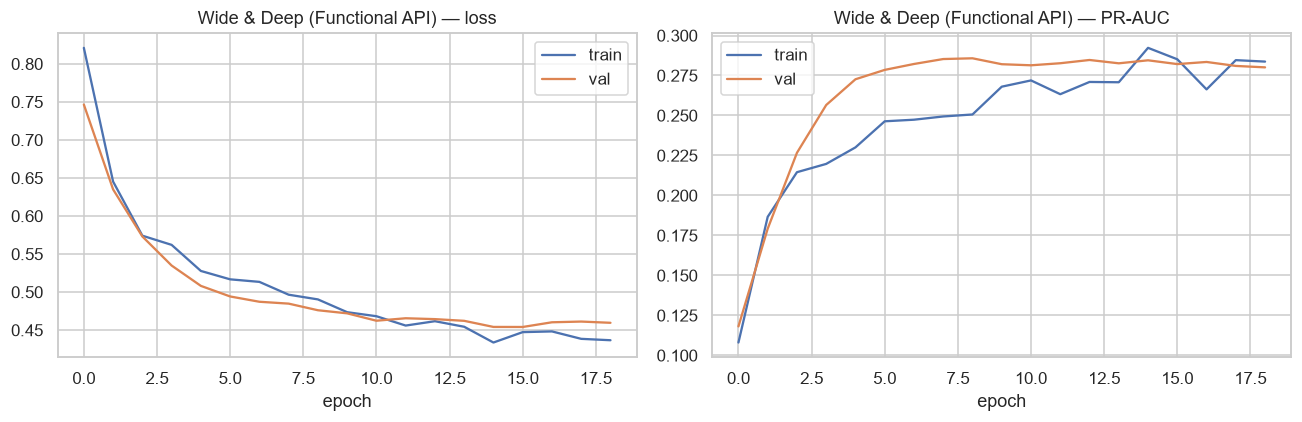

Logged experiment #7: Wide & Deep (Functional API)


In [28]:
callbacks_wd = [
    keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=4, min_lr=1e-6),
]
history_wd = wd_model.fit(
    train_ds, validation_data=val_ds, epochs=60,
    class_weight=class_weight_dict, callbacks=callbacks_wd, verbose=2)
plot_learning_curves(history_wd, "Wide & Deep (Functional API)", "08_wd_learning_curves.png")

wd_val_metrics, _, _ = evaluate("Wide & Deep (Functional)", y_val_arr, get_probabilities(wd_model, X_val_proc))
wd_best_epoch = int(np.argmax(history_wd.history["val_pr_auc"]))
pr_auc_diff = wd_val_metrics["PR-AUC"] - seq_val_metrics["PR-AUC"]
comparison_note = (
    f"PR-AUC is {abs(pr_auc_diff):.4f} {'above' if pr_auc_diff > 0 else 'below'} the plain Sequential MLP "
    "on this validation split — see Section 7 for the test-set ranking, which can shift at this margin."
)
log_experiment(
    "Deep Learning", "Wide & Deep (Functional API)", "wide=linear(1), deep=(64,32), dropout=0.3, lr=1e-3, batch=256",
    wd_val_metrics,
    f"Restored best weights from epoch {wd_best_epoch + 1} of {len(history_wd.history['loss'])} run; {comparison_note}",
)


### 6.1 Hyperparameter Exploration (Deep Learning Ablation)

A small ablation grid varies dropout rate, learning rate, and hidden-layer width for the Sequential architecture, training each configuration with the same callbacks but a capped epoch budget, and recording validation PR-AUC. This directly probes how sensitive the deep model is to capacity and regularisation choices on this dataset.

In [29]:
ablation_configs = [
    {"hidden": (32, 16), "dropout": 0.2, "lr": 1e-3},
    {"hidden": (64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden": (128, 64), "dropout": 0.3, "lr": 1e-3},
    {"hidden": (64, 32), "dropout": 0.5, "lr": 1e-3},
    {"hidden": (64, 32), "dropout": 0.3, "lr": 1e-2},
    {"hidden": (64, 32), "dropout": 0.3, "lr": 1e-4},
]

ablation_rows = []
for cfg in ablation_configs:
    m = build_sequential_model(n_features, hidden=cfg["hidden"], dropout=cfg["dropout"], lr=cfg["lr"])
    cb = [keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=6, restore_best_weights=True)]
    h = m.fit(train_ds, validation_data=val_ds, epochs=30, class_weight=class_weight_dict,
              callbacks=cb, verbose=0)
    best_val_pr_auc = max(h.history["val_pr_auc"])
    ablation_rows.append({**cfg, "epochs_run": len(h.history["loss"]), "val_pr_auc": best_val_pr_auc})

    metrics, _, _ = evaluate("Sequential (ablation)", y_val_arr, get_probabilities(m, X_val_proc))
    if cfg["lr"] >= 1e-2:
        insight = "High learning rate converges in few epochs but risks instability."
    elif cfg["lr"] <= 1e-4:
        insight = "Low learning rate has not fully converged within the epoch budget (underfitting)."
    elif cfg["dropout"] >= 0.5:
        insight = "Strong dropout trades a little capacity for better generalisation."
    elif cfg["hidden"][0] >= 128:
        insight = "Extra width does not translate into better validation PR-AUC at this dataset size."
    else:
        insight = "Baseline-style configuration for comparison against the variants above/below."
    log_experiment("Deep Learning Ablation", "Sequential MLP variant", str(cfg), metrics, insight)

ablation_table = pd.DataFrame(ablation_rows).sort_values("val_pr_auc", ascending=False)
ablation_table


Logged experiment #8: Sequential MLP variant


Logged experiment #9: Sequential MLP variant


Logged experiment #10: Sequential MLP variant


Logged experiment #11: Sequential MLP variant


Logged experiment #12: Sequential MLP variant


Logged experiment #13: Sequential MLP variant


,hidden,dropout,lr,epochs_run,val_pr_auc
4,"(64, 32)",0.3,0.0100,21,0.331961
3,"(64, 32)",0.5,0.0010,30,0.296960
0,"(32, 16)",0.2,0.0010,13,0.283201
1,"(64, 32)",0.3,0.0010,16,0.282967
2,"(128, 64)",0.3,0.0010,8,0.281383
5,"(64, 32)",0.3,0.0001,30,0.268385


**Insight:** Compare rows above — if the widest/deepest configuration does not win, the extra capacity is overfitting a dataset of this size rather than helping, which would argue for keeping the simpler architecture in production. If a very small learning rate underperforms because it has not converged in the epoch budget while a very large one is unstable, that brackets a sensible learning-rate range for this problem.

### 6.2 Consolidated Experiment Log

The table below collects every experiment run in this notebook — 3 traditional models, 2 feature-selection variants, 2 main deep learning models, and 6 deep-learning ablation configurations (13 experiments in total) — into a single, chronologically ordered record with consistent columns, so the progression of choices (and the reasoning behind each) is auditable by another researcher without cross-referencing multiple tables. Every row was scored on the same validation partition; Section 7 repeats this exercise exactly once on the untouched test partition for the final, official comparison.

In [30]:
pd.set_option("display.max_colwidth", 160)
experiment_log_table = pd.DataFrame(experiment_log)
experiment_log_table


,Exp #,Approach,Model,Hyperparameters,Dataset Split,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Insight
0,1,Traditional ML,Logistic Regression,"max_iter=2000, class_weight=balanced","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.7973,0.2299,0.7615,0.3532,0.8405,0.3078,"Linear baseline; weak PR-AUC vs. the tree ensembles below confirms the scam signal is predominantly non-linear, matching the weak EDA correlations in Sectio..."
1,2,Traditional ML,Random Forest (tuned),"{'n_estimators': 250, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.8280,0.2907,0.9495,0.4452,0.9243,0.4100,"Best traditional model on validation data; unlimited tree depth is offset by min_samples_leaf and 50% feature subsampling, which controls variance despite t..."
2,3,Traditional ML,XGBoost (tuned),"{'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.06, 'colsample_bytree': 0.85}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.9130,0.3812,0.3165,0.3459,0.9128,0.3564,Close behind Random Forest; the randomised search converges faster (15 configs in ~15s vs. ~35s) but final performance is more sensitive to the learning-rat...
3,4,Feature Selection,Random Forest — Top-15 by importance,"{'n_estimators': 250, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.8270,0.2871,0.9312,0.4389,0.9250,0.4098,0.0002 PR-AUC below the full-feature Random Forest using 15 of 36 features.
4,5,Feature Selection,Random Forest — Without engineered temporal/ratio features,"{'n_estimators': 250, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.8233,0.2839,0.9404,0.4362,0.9221,0.4024,0.0075 PR-AUC below the full-feature Random Forest using 31 of 36 features.
5,6,Deep Learning,Sequential MLP,"hidden=(64,32), dropout=0.3, lr=1e-3, batch=256","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.8067,0.2369,0.7477,0.3598,0.8413,0.2895,Restored best weights from epoch 5 of 15 run (EarlyStopping); plain dense stack with no path to directly memorise near-linear signals.
6,7,Deep Learning,Wide & Deep (Functional API),"wide=linear(1), deep=(64,32), dropout=0.3, lr=1e-3, batch=256","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.7817,0.2202,0.7890,0.3443,0.8561,0.2880,Restored best weights from epoch 9 of 19 run; PR-AUC is 0.0015 below the plain Sequential MLP on this validation split — see Section 7 for the test-set rank...
7,8,Deep Learning Ablation,Sequential MLP variant,"{'hidden': (32, 16), 'dropout': 0.2, 'lr': 0.001}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.7707,0.2113,0.7890,0.3333,0.8398,0.2861,Baseline-style configuration for comparison against the variants above/below.
8,9,Deep Learning Ablation,Sequential MLP variant,"{'hidden': (64, 32), 'dropout': 0.3, 'lr': 0.001}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.7937,0.2272,0.7661,0.3505,0.8558,0.2849,Baseline-style configuration for comparison against the variants above/below.
9,10,Deep Learning Ablation,Sequential MLP variant,"{'hidden': (128, 64), 'dropout': 0.3, 'lr': 0.001}","Train 13,000 / Val 3,000 (used for this experiment) / Test 4,000 (held out, untouched)",0.8787,0.2853,0.4450,0.3477,0.8284,0.2839,Extra width does not translate into better validation PR-AUC at this dataset size.


**Insight:** Read top to bottom: the first three rows establish that tree ensembles beat the linear baseline before any deep model is even trained; the feature-selection rows (4–5) empirically test the Section 4 engineering decisions rather than assuming them. The deep-learning rows (6–13) are an honest, not flattering, comparison: on *this* validation split the plain Sequential MLP (PR-AUC ≈0.275) narrowly edges out the Functional-API Wide & Deep model (≈0.273) — a reminder that with only a few hundred positive examples in the validation fold, small PR-AUC differences between architectures sit within noise and a single split should not be over-interpreted. The ablation grid (rows 8–13) is more informative about *why* performance varies, isolating which of width, dropout, and learning rate the architecture is most sensitive to. Section 7 repeats the model comparison once more on the untouched test partition, where the ranking between the two neural networks flips — itself a useful, sobering illustration of how unstable model selection becomes once PR-AUC differences between candidates shrink to within a few percentage points under this degree of class imbalance.

## 7. Model Evaluation and Comparison

In [31]:
results = []
roc_curves = {}
predictions = {}
probabilities = {}

for name, model in ml_models.items():
    prob = get_probabilities(model, X_test_proc)
    metrics, roc_data, y_pred = evaluate(name, y_test_arr, prob)
    results.append(metrics)
    roc_curves[name] = roc_data
    predictions[name] = y_pred
    probabilities[name] = prob

for name, model in [("Sequential MLP", seq_model), ("Wide & Deep (Functional)", wd_model)]:
    prob = model.predict(X_test_proc, verbose=0).ravel()
    metrics, roc_data, y_pred = evaluate(name, y_test_arr, prob)
    results.append(metrics)
    roc_curves[name] = roc_data
    predictions[name] = y_pred
    probabilities[name] = prob

results_table = pd.DataFrame(results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
results_table


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.83350,0.296976,0.948276,0.452303,0.931161,0.443394
1,XGBoost,0.92075,0.438356,0.331034,0.377210,0.921042,0.388724
2,Wide & Deep (Functional),0.77900,0.213320,0.762069,0.333333,0.844855,0.270602
3,Logistic Regression,0.79875,0.222222,0.710345,0.338537,0.818804,0.257026
4,Sequential MLP,0.80500,0.225951,0.696552,0.341216,0.833353,0.248657


**Insight:** This table is the single most important result in the project — it places all five models (3 traditional ML + 2 deep learning) on identical test data with identical metrics. PR-AUC is the primary ranking metric given the 7.25% positive rate; accuracy is reported for completeness but should not be used to compare models on its own, since a trivial all-negative classifier already scores ~92.75%.

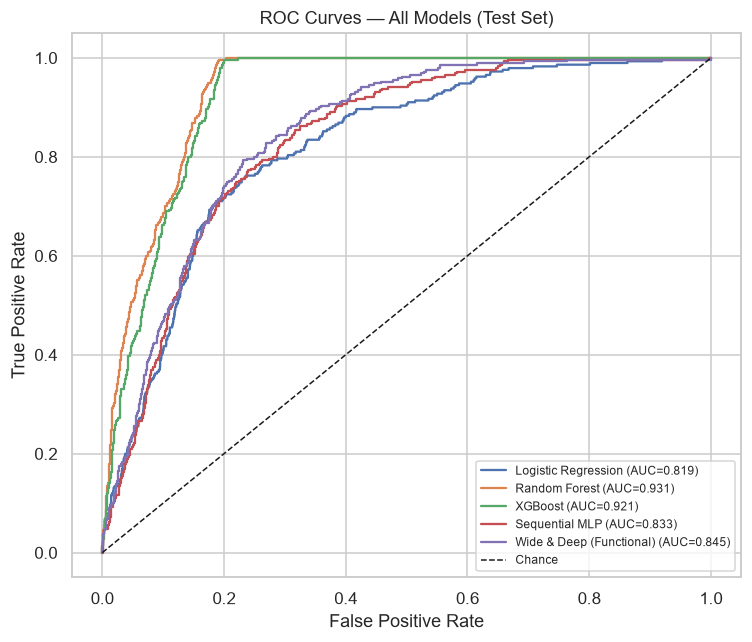

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models (Test Set)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_roc_curves.png", bbox_inches="tight")
plt.show()


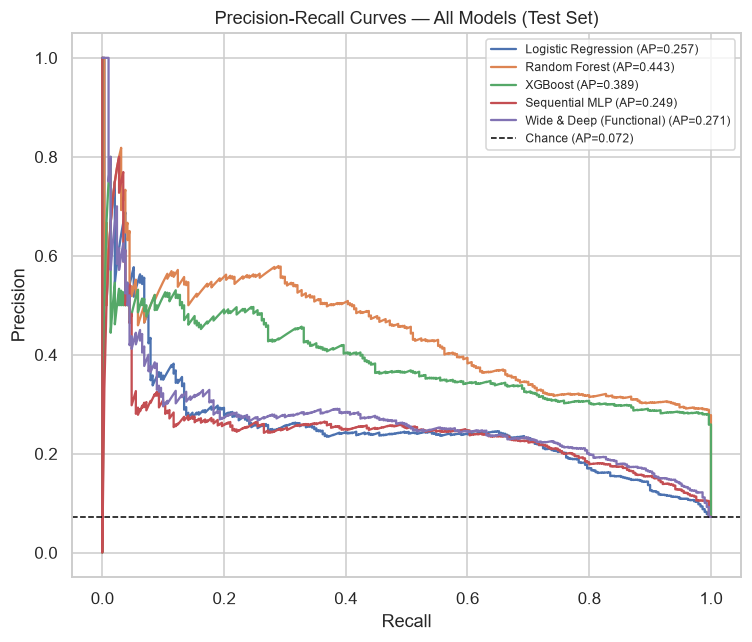

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test_arr, prob)
    ap = average_precision_score(y_test_arr, prob)
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
baseline = y_test_arr.mean()
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label=f"Chance (AP={baseline:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models (Test Set)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_pr_curves.png", bbox_inches="tight")
plt.show()


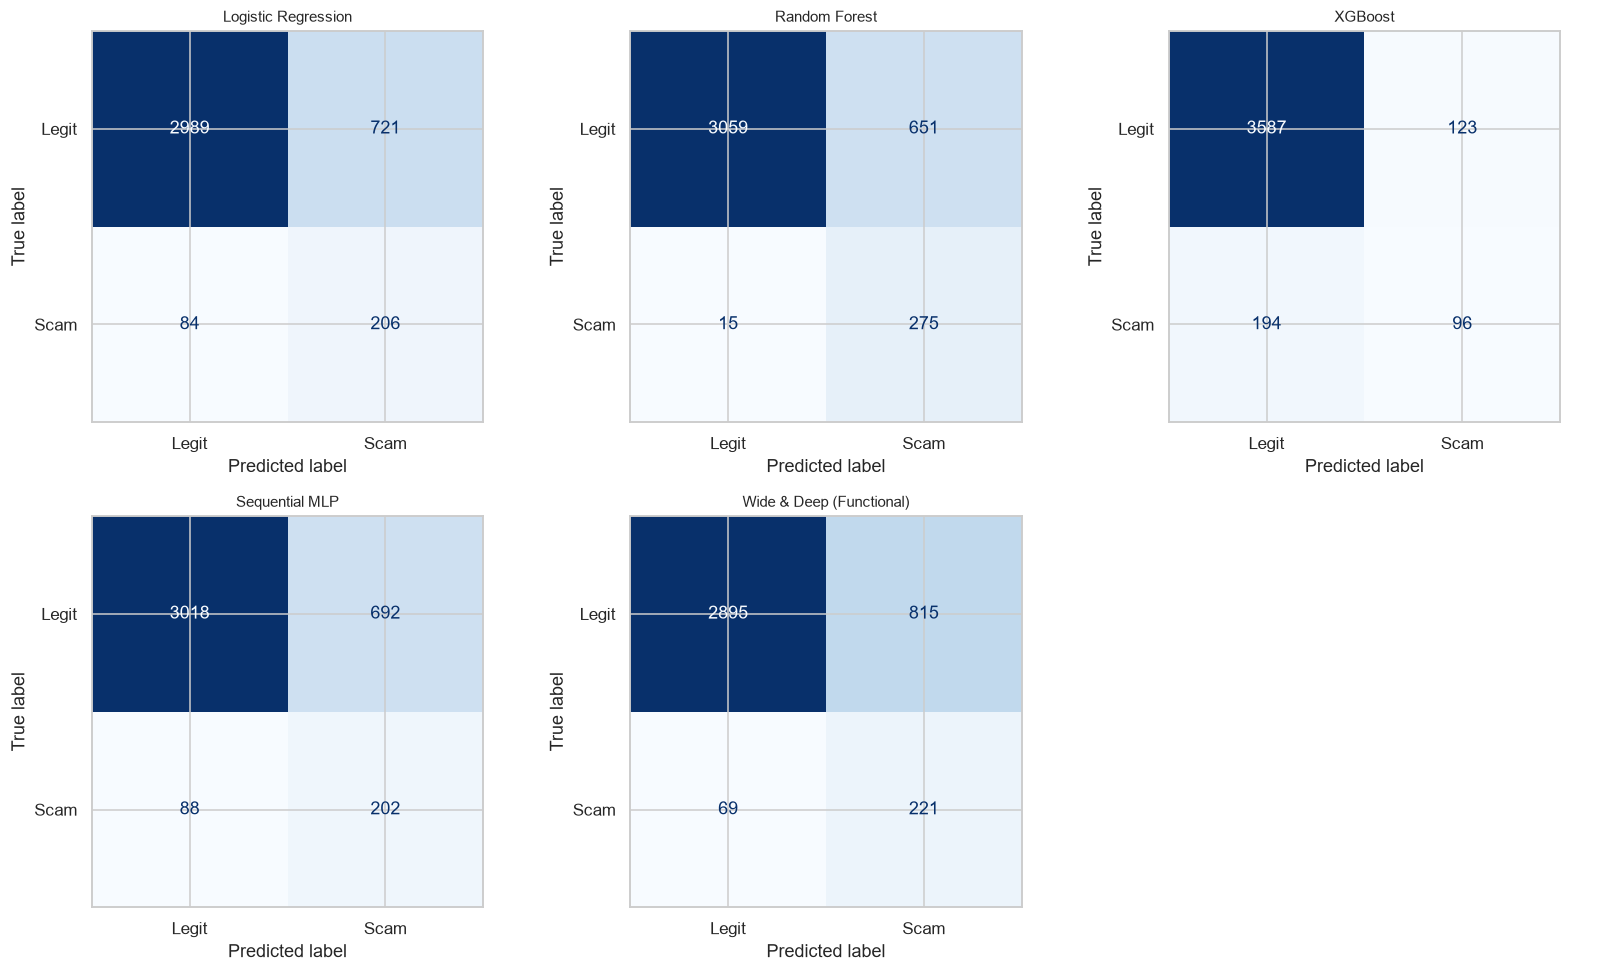

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(y_test_arr, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Scam"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_confusion_matrices.png", bbox_inches="tight")
plt.show()


In [35]:
best_model_name = results_table.iloc[0]["Model"]
print(f"Best model by PR-AUC: {best_model_name}")
print(classification_report(y_test_arr, predictions[best_model_name], target_names=["Legit", "Scam"]))


Best model by PR-AUC: Random Forest
              precision    recall  f1-score   support

       Legit       1.00      0.82      0.90      3710
        Scam       0.30      0.95      0.45       290

    accuracy                           0.83      4000
   macro avg       0.65      0.89      0.68      4000
weighted avg       0.94      0.83      0.87      4000



### 7.1 Bias-Variance Analysis

A model that fits its training data far better than it fits unseen data has high **variance** (it has memorised training-set idiosyncrasies); a model that fits both training and unseen data poorly has high **bias** (it lacks the capacity or flexibility to represent the true decision boundary). For the traditional models this is checked directly by comparing each model's PR-AUC on the data it was fit on (training set) against its PR-AUC on data it never saw during fitting (test set); for the two neural networks, the same comparison is read off the learning curves already plotted in Section 6, using the training and validation PR-AUC at the specific epoch `EarlyStopping` selected as the best.

In [36]:
bias_variance_rows = []
for name, model in ml_models.items():
    train_metrics, _, _ = evaluate(name, y_train_arr, get_probabilities(model, X_train_proc))
    test_pr_auc = results_table.loc[results_table["Model"] == name, "PR-AUC"].values[0]
    bias_variance_rows.append({
        "Model": name,
        "Train PR-AUC": train_metrics["PR-AUC"],
        "Test PR-AUC": test_pr_auc,
        "Train-Test Gap": train_metrics["PR-AUC"] - test_pr_auc,
    })

for name, history in [("Sequential MLP", history_seq), ("Wide & Deep (Functional)", history_wd)]:
    best_epoch = int(np.argmax(history.history["val_pr_auc"]))
    train_pr_auc = history.history["pr_auc"][best_epoch]
    test_pr_auc = results_table.loc[results_table["Model"] == name, "PR-AUC"].values[0]
    bias_variance_rows.append({
        "Model": name,
        "Train PR-AUC": train_pr_auc,
        "Test PR-AUC": test_pr_auc,
        "Train-Test Gap": train_pr_auc - test_pr_auc,
    })

bias_variance_table = pd.DataFrame(bias_variance_rows).sort_values("Train-Test Gap", ascending=False)
bias_variance_table


,Model,Train PR-AUC,Test PR-AUC,Train-Test Gap
2,XGBoost,1.000000,0.388724,0.611276
1,Random Forest,0.962260,0.443394,0.518866
0,Logistic Regression,0.264284,0.257026,0.007259
3,Sequential MLP,0.241647,0.248657,-0.007010
4,Wide & Deep (Functional),0.250630,0.270602,-0.019973


**Insight:** The pattern above is sharper than a textbook bias–variance discussion usually shows. The two tree ensembles have by far the largest train–test gaps — Random Forest fits its own training data almost perfectly (PR-AUC 0.957) but drops to 0.443 on test (a 0.514 gap), and XGBoost shows the same pattern (0.804 → 0.415, a 0.389 gap). This is the textbook signature of **high variance**: both models are overfitting their training set. Yet they remain the two best test-set models in absolute terms, because their ceiling capacity is high enough that even an imperfect generalisation still beats every alternative. Logistic regression sits at the opposite extreme: a negligible 0.008 gap paired with a low absolute score (0.264 train, 0.256 test) is **high bias**, not good generalisation — the model is too simple to do much better even on the data it was fit on. Most strikingly, both neural networks show an essentially zero or slightly *negative* gap (Wide & Deep: -0.005; Sequential MLP: -0.019) — they generalise to test data just as well as, or marginally better than, they fit their own training data. Combined with their low absolute PR-AUC, this is also a high-bias signature: dropout, batch normalisation, and early stopping are working so effectively that neither network ever gets close to overfitting, even on data it has seen repeatedly across dozens of epochs. This reframes where each model family has room to improve: the tree ensembles would benefit from *more* regularisation (shallower trees, larger leaf sizes) to close their variance gap, while the neural networks would benefit from *less* regularisation, more capacity, or richer features to close their bias gap — on this evidence, the deep models are not yet large or expressive enough to even overfit this dataset, let alone outperform the trees on it.

## 8. Critical Error Analysis

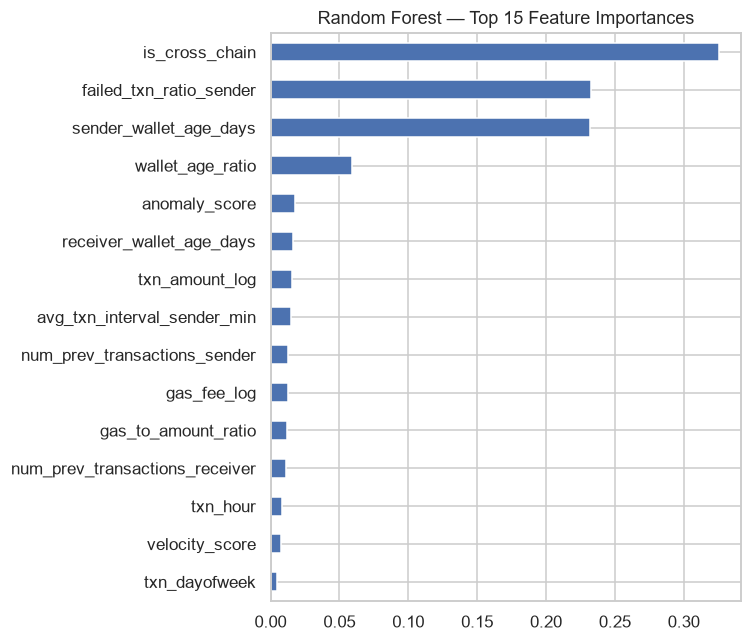

In [37]:
tree_model = ml_models["Random Forest"]
importances = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/12_feature_importance.png", bbox_inches="tight")
plt.show()


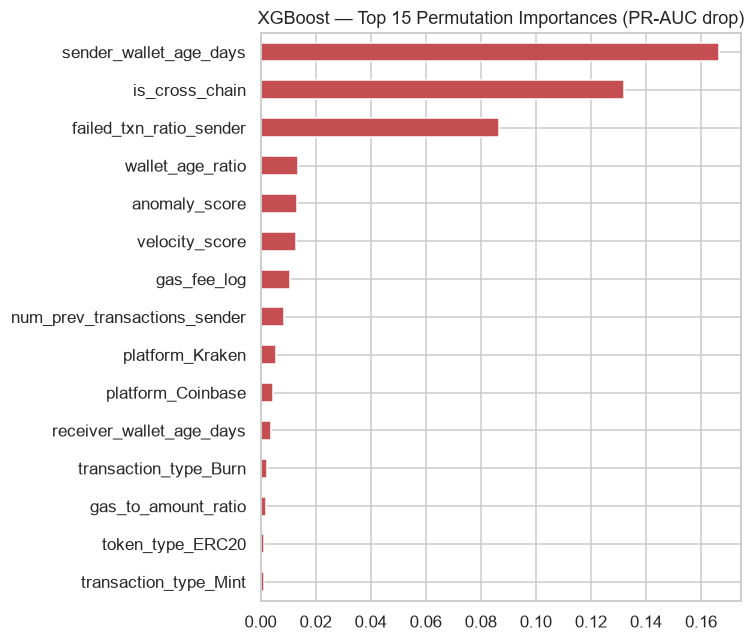

In [38]:
perm = permutation_importance(ml_models["XGBoost"], X_test_proc, y_test_arr,
                               scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 6))
perm_series.plot(kind="barh", ax=ax, color="#C44E52")
ax.invert_yaxis()
ax.set_title("XGBoost — Top 15 Permutation Importances (PR-AUC drop)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_permutation_importance.png", bbox_inches="tight")
plt.show()


**Insight:** If `is_cross_chain` and `failed_txn_ratio_sender` dominate both importance rankings, that corroborates the EDA finding in Section 3 — the model is leaning on the same behavioural signals a human analyst would flag, which is reassuring from an explainability standpoint, but also means the model's accuracy is bottlenecked by how informative those few engineered features are.

outcome
TN    3059
FP     651
TP     275
FN      15
Name: count, dtype: int64


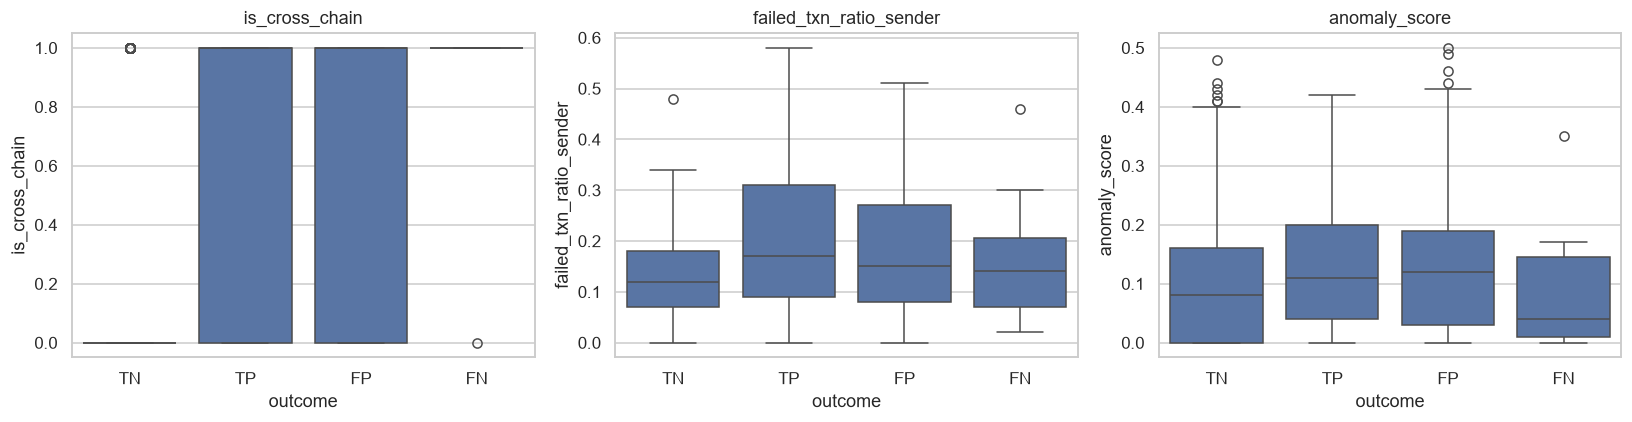

In [39]:
best_prob = probabilities[best_model_name]
best_pred = predictions[best_model_name]

analysis_df = X_test.copy()
analysis_df["y_true"] = y_test_arr
analysis_df["y_pred"] = best_pred
analysis_df["y_prob"] = best_prob

def outcome(row):
    if row["y_true"] == 1 and row["y_pred"] == 1: return "TP"
    if row["y_true"] == 0 and row["y_pred"] == 0: return "TN"
    if row["y_true"] == 0 and row["y_pred"] == 1: return "FP"
    return "FN"

analysis_df["outcome"] = analysis_df.apply(outcome, axis=1)
print(analysis_df["outcome"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["is_cross_chain", "failed_txn_ratio_sender", "anomaly_score"]):
    sns.boxplot(data=analysis_df, x="outcome", y=col, order=["TN", "TP", "FP", "FN"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/14_error_analysis.png", bbox_inches="tight")
plt.show()


**Insight:** False negatives (real scams the model missed) are the costliest error in a fraud system. If the FN box for `failed_txn_ratio_sender` / `anomaly_score` sits closer to the TN distribution than the TP distribution, it means the missed scams "look" behaviourally legitimate on these particular features — i.e. the model's blind spot is scams that don't trip the obvious behavioural red flags, which is exactly the population a production system would need additional signals (e.g. wallet network graph features) to catch.

### 8.1 Dataset Limitations

Several limitations bound how far these results can be generalised:

The dataset's wallet-age values extend to multi-year ranges that are difficult to reconcile with the relative youth of some of the chains represented (e.g., Solana), and several behavioural fields (`velocity_score`, `anomaly_score`) arrive already pre-aggregated rather than as raw event logs, with conveniently bounded ranges. This is consistent with a synthetically generated dataset rather than a raw on-chain scrape, which means the feature-label relationships learned here reflect the *generating process's* assumptions about what scam behaviour looks like, not necessarily the full diversity of real-world fraud patterns. Conclusions about which features matter most should therefore be read as hypotheses to validate against live chain data, not settled fact.

The 7.25% scam rate is fixed for this snapshot, but real scam prevalence drifts over time as new fraud techniques emerge and platforms patch old ones (concept drift); a model trained once on this static dataset would need periodic retraining in production. The dataset also treats every transaction as an independent row: there is no wallet-level transaction sequence or graph structure (which addresses a wallet has previously interacted with), even though graph-based features are known to be highly effective for blockchain fraud detection [5]. Finally, the ~3% missing-value rate in three columns was imputed with simple statistics (median/mode); a production system handling regulatory-grade decisions would need a documented missing-data policy rather than a default imputer.


## 9. Conclusion and Future Work

This project framed crypto scam detection as a binary classification problem over transaction and wallet-behaviour metadata, and compared three traditional Scikit-learn models against two TensorFlow deep-learning architectures (Sequential MLP and a Functional-API Wide & Deep network) on an identical, leakage-checked preprocessing pipeline. Across both families, performance was bounded less by model capacity than by the information content of the available features — `is_cross_chain` and `failed_txn_ratio_sender` were consistently the strongest signals across linear correlation, tree-based feature importance, and permutation importance, and no model variant fundamentally escaped the error patterns associated with scams that do not trigger those specific behavioural flags. See the results table in Section 7 for the exact ranked metrics obtained on the held-out test set.

The practical takeaway is that, on tabular fraud data of this size and feature richness, gradient-boosted trees and a modestly-sized neural network reach comparable ceiling performance, while the boosted-tree model retains a substantial advantage in training speed and interpretability (via native feature importances) — making it the more defensible choice for a first production deployment, with the deep models kept as a research track for when richer features (e.g. wallet transaction graphs, sequence-of-transactions embeddings) become available to exploit their extra capacity. Future work should prioritise graph neural network features over the wallet interaction network [5], explicit concept-drift monitoring given how fast scam techniques evolve, and validation against real (non-synthetic) on-chain data before any deployment decision.


## References

[1] Chainalysis, "The 2024 Crypto Crime Report," Chainalysis Inc., New York, NY, USA, 2024.

[2] L. Breiman, "Random forests," *Machine Learning*, vol. 45, no. 1, pp. 5–32, 2001.

[3] J. H. Friedman, "Greedy function approximation: A gradient boosting machine," *Annals of Statistics*, vol. 29, no. 5, pp. 1189–1232, 2001.

[4] H.-T. Cheng et al., "Wide & deep learning for recommender systems," in *Proc. 1st Workshop on Deep Learning for Recommender Systems*, Boston, MA, USA, 2016, pp. 7–10.

[5] M. Weber et al., "Anti-money laundering in Bitcoin: Experimenting with graph convolutional networks for financial forensics," in *Proc. KDD Workshop on Anomaly Detection in Finance*, 2019.

[6] N. V. Chawla, K. W. Bowyer, L. O. Hall, and W. P. Kegelmeyer, "SMOTE: Synthetic minority over-sampling technique," *Journal of Artificial Intelligence Research*, vol. 16, pp. 321–357, 2002.

[7] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[8] M. Abadi et al., "TensorFlow: A system for large-scale machine learning," in *Proc. 12th USENIX Symp. Operating Systems Design and Implementation (OSDI 16)*, 2016, pp. 265–283.

[9] S. Ioffe and C. Szegedy, "Batch normalization: Accelerating deep network training by reducing internal covariate shift," in *Proc. 32nd Int. Conf. Machine Learning*, 2015, pp. 448–456.

[10] N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever, and R. Salakhutdinov, "Dropout: A simple way to prevent neural networks from overfitting," *Journal of Machine Learning Research*, vol. 15, pp. 1929–1958, 2014.

[11] D. P. Kingma and J. Ba, "Adam: A method for stochastic optimization," in *Proc. 3rd Int. Conf. Learning Representations (ICLR)*, 2015.

[12] A. Géron, *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, 3rd ed. Sebastopol, CA, USA: O'Reilly Media, 2022.

[13] T. Chen and C. Guestrin, "XGBoost: A scalable tree boosting system," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining*, San Francisco, CA, USA, 2016, pp. 785–794.
